# 05 – K-Nearest Neighbors

Review 1 Part-A classification.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from classification_utils import (
    load_data,
    prepare_target,
    make_split,
    make_preprocessor,
    make_pipeline
)


# Load dataset
df, feature_cols = prepare_target(
    load_data()
)


# Stratified 80:20 train-test split
X_train, X_test, y_train, y_test, le = make_split(
    df,
    feature_cols
)


# Preprocessing
preprocessor = make_preprocessor(
    X_train
)


# KNN model
model = KNeighborsClassifier(
    n_neighbors=5
)


# Complete preprocessing + model pipeline
pipe = make_pipeline(
    model,
    preprocessor
)


# Train model
pipe.fit(
    X_train,
    y_train
)


# Predictions
y_pred = pipe.predict(
    X_test
)


# Evaluation metrics
metrics = {
    "Model": "K-Nearest Neighbors",
    "Accuracy": accuracy_score(
        y_test,
        y_pred
    ),
    "Precision": precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    ),
    "Weighted F1": f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )
}


# Display metrics
results = pd.DataFrame([metrics])

display(
    results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "Weighted F1": "{:.4f}"
    })
)


# Classification report
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_,
        zero_division=0
    )
)

,Model,Accuracy,Precision,Recall,Weighted F1
0,K-Nearest Neighbors,0.7352,0.7448,0.7352,0.7314


Classification Report:
              precision    recall  f1-score   support

       Bumps       0.56      0.73      0.63        81
   Dirtiness       0.90      0.82      0.86        11
    K_Scatch       0.97      0.96      0.97        78
Other_Faults       0.69      0.64      0.67       135
      Pastry       0.73      0.34      0.47        32
      Stains       0.71      0.71      0.71        14
   Z_Scratch       0.83      0.92      0.88        38

    accuracy                           0.74       389
   macro avg       0.77      0.73      0.74       389
weighted avg       0.74      0.74      0.73       389



## Confusion Matrix

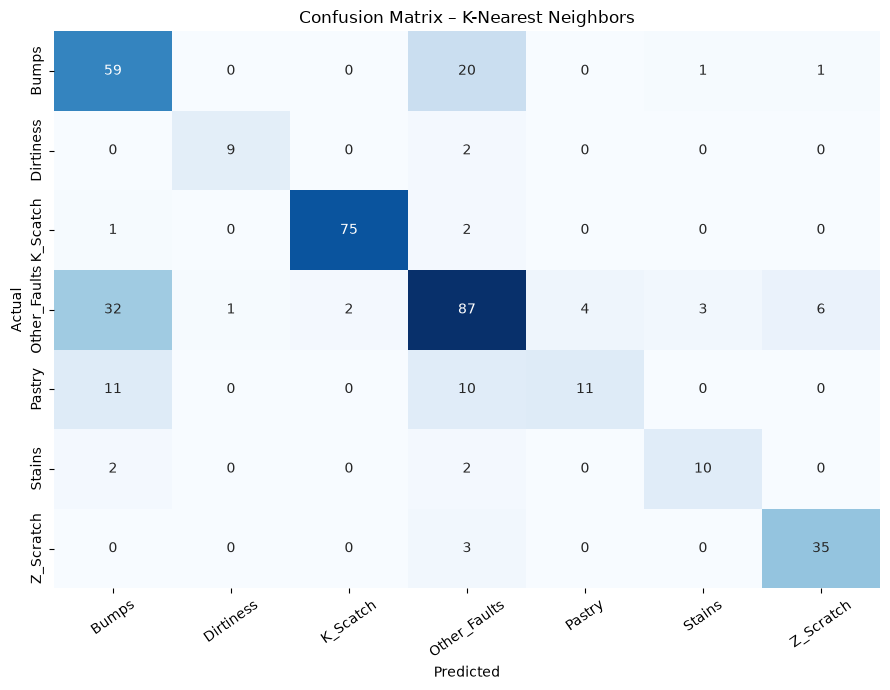

In [3]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title(
    "Confusion Matrix – K-Nearest Neighbors"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

### Observation

Cells along the diagonal of the confusion matrix refer to accurate predictions, and cells off-diagonal to fault-type confusions. The Accuracy, Precision, Recall and F1 above show the performance of the model on the test data set.